# Способы ускорения поиска

План:
- Хеш-функции
- Индексы
- BallTree, KD-Tree

## Хеш-фукнции

__Хеш-функция__ - это фукнция, которая преобразует массив входных данных в последовательность бит фиксированной длины.

Хеш-функции чаще всего используются для эффективной работы с большим объемом данных, но не только.

__С помощью них реализовано:__
- Создание ассоциативных массивов (словари в питоне). Именно поэтому ключи должны быть hashable;
- Проверка целостности файлов: метод контрольных сумм;
- Криптография: с помощью хеш-функций генерируются токены (но здесь список требуемых свойств сильно длиннее, чем тот, что приведен ниже).

__Хеш-функции должны обладать следующими свойствами:__
- Детерминированность - для одного и того же входного значения результат всегда должен быть одинаковым;
- Равномерность - выходные значения должны равномерно распределяться по всему диапазону возможных значений;
- Эффективность - результат функции должен вычисляться достаточно быстро, чтобы не замедлять последующие операции;
- Отсутствие (или хотя бы минимум) коллизий - должно быть как можно меньше сиуаций, когда разные входные значения имеют одинаковые хеши.

__Какие из приведенных функций лучше удовлетворяют требованиям?__
Мы хотим разделить все объекты на группы с помощью хеш-функции для ускорения поиска и удобства хранения.

- Первая буква как хеш для слов в словаре;
- Первая буква имени как хеш для клиента компании;
- Дата рождения как хеш для клиента компании;
- Случайное число как хеш для файла при распределенном хранении;
- Последние четыре цифры номера телефона;

В питоне есть функция `hash`, которая дла hashable объектов умеет возвращать их хеш.

In [ ]:
s = 'Hello, World!'
hash(s)

9027679148858096972

На самом деле внутри себя она вызывает метод `__hash__` от того объекта, которые ей выдали

In [ ]:
s.__hash__()

9027679148858096972

Зная это, мы можем немного сломать питон (но не надо так делать в жизни!)

In [ ]:
class StrangeHashableList(list):
    def __hash__(self):
        return len(self)

In [ ]:
lst = StrangeHashableList()
lst.extend([1, 2, 3])

In [ ]:
dct = dict()
dct[lst] = 0
dct

{[1, 2, 3]: 0}

Также в питоне есть отдельная библиотека `hashlib`, которая позволяет выбирать из множества алгоритмов хеширования. Если вам нужны хеши для каких-то специфических задач, то лучше использовать ее.

In [ ]:
import hashlib
hashlib.sha256(b"Nobody inspects the spammish repetition").hexdigest()

'031edd7d41651593c5fe5c006fa5752b37fddff7bc4e843aa6af0c950f4b9406'

## Индексы

Иногда сортировка непосредственно данных может быть затруднена или невозможна. Например, если мы храним большой объем данных по каждому жителю Китая, Индии и США, то получается, что мы могли бы отсортировать такой объем чисел, но нам затруднительно отсортировать сами данные, так как манипуляции с такими объемами займут много времени. В таком случае можно построить __индекс__ - специальную структуру, ускоряющую поиск по массиву данных. Сам процесс ее построения называется __индексацией__.

Давайте создадим список, который будет хранить порядковые номера хранимых объектов. Дальше вместо того, чтобы обращаться к элементу с номером i, мы будем брать i-й элемент индекса и обращаться к элементу с полученным номером. Если считать, что данные хранятся в списке data, а индекс в списке index, то вместо обращения `data[i]` мы будем использовать `data[index[i]]`.

In [ ]:
data = [
    {'name': 'Ann', 'age': 17, 'city': 'Moscow'},
    {'name': 'Max', 'age': 25, 'city': 'New-York'},
    {'name': 'Kate', 'age': 31, 'city': 'Berlin'},
    {'name': 'Trevor', 'age': 15, 'city': 'London'}
]
index = list(range(len(data)))
index

[0, 1, 2, 3]

In [ ]:
idx = 2
data[index[idx]]

{'name': 'Kate', 'age': 31, 'city': 'Berlin'}

Теперь вместо того, чтобы перемещать элемент в самом списке данных, мы будем изменять его номер в индексе. При сортировке это означает, что вместо перемещения элементов мы будем менять местами их индексы. Индекс будет показывать, в каком порядке следует взять элементы данных, для того, чтобы они шли в отсортированном виде.

Отсортируем наших ребят по алфавиту:

In [ ]:
name_index = sorted(index, key=lambda x: data[x]['name'])
name_index

[0, 2, 1, 3]

In [ ]:
[data[idx] for idx in name_index]

[{'name': 'Ann', 'age': 17, 'city': 'Moscow'},
 {'name': 'Kate', 'age': 31, 'city': 'Berlin'},
 {'name': 'Max', 'age': 25, 'city': 'New-York'},
 {'name': 'Trevor', 'age': 15, 'city': 'London'}]

Такой подход особенно удобен, когда нам надо иметь несколько сортировок. Вместо того, чтобы сортировать каждый раз перед поиском, мы стрим несколько индексов, которые используем в зависимости от поставленной задачи.

Отсортируем список по возрасту:

In [ ]:
age_index = sorted(index, key=lambda x: data[x]['age'])
age_index

[3, 0, 1, 2]

In [ ]:
[data[idx] for idx in age_index]

[{'name': 'Trevor', 'age': 15, 'city': 'London'},
 {'name': 'Ann', 'age': 17, 'city': 'Moscow'},
 {'name': 'Max', 'age': 25, 'city': 'New-York'},
 {'name': 'Kate', 'age': 31, 'city': 'Berlin'}]

Правда, в Питоне мы не ощутим всей мощи этого подхода в смысле скорости, так как Питон перемещает не сами переменные, а ссылки на них. Но удобство использования нескольких списков остается. Более того, эта идея подводит нас к следующему интересному решению.

Пусть у нас имеется длинный список больших текстов, в котором нам необходимо искать другие приходящие тексты. (В качестве альтернативы можно считать, что мы обрабатываем ДНК). Пусть нас интересет только полное совпадение текстов.

Оказывается, что вместо длинного текста мы можем взять его короткого представителя, который будет гораздо проще сравнивать с другими такими представителями.

In [ ]:
texts = ["Правда, в Питоне мы не ощутим всей мощи этого подхода в смысле скорости, так как Питон перемещает не сами переменные, а ссылки на них. Но удобство использования нескольких списков сотается. Более того, эта идея подводит нас к следующему интересному решению.",
 "Пусть у нас имеется длинный список больших текстов, в котором нам необходимо искать другие приходящие тексты. (В качестве альтернативы можно считать, что мы обрабатываем ДНК). Пусть нас интересет только полное совпадение текстов.",
 "Хеш-функция, или функция свёртки — функция, осуществляющая преобразование массива входных данных произвольной длины в (выходную) битовую строку установленной длины, выполняемое определённым алгоритмом.",
 "Для нас сейчас важно следующее. Вместо длинного текста мы можем взять его короткого представителя, который будет гораздо проще сравнивать с другими такими представителями. Для расчета хеш-значений в Питоне имеется библиотека hashlib. Используем ее."
]

hashs = [(hashlib.md5(t.encode()).hexdigest(), i) for i, t in enumerate(texts)]
hashs = sorted(hashs, key=lambda x: x[0])
hashs

[('42d6964546cbee31aa96b9adc86545c8', 1),
 ('66ac294d0ab4568dd2b0b4e49511b76f', 3),
 ('6c4f1f50509c683ee6376e7353b485c3', 0),
 ('ae02bb40472369d133c371ed56a4e90b', 2)]

А еще мы можем положить хеши в двоичное дерево и еще ускорить поиск :)

## BallTree & KD-Tree

### KD-Tree

KD-Tree - это структура данных для храения точек в k-мерном пространстве с возможностью быстрого поиска по ним.

<img src="https://www.researchgate.net/publication/251813225/figure/fig1/AS:341656336388110@1458468626545/A-kd-tree-example-subdivided-data-left-and-the-corresponding-binary-tree-right.png">

Алгоритм построения:
1. Берем координату, считаем для нее медиану (часто координату выбирают по принципу максимизации дисперсии). По этой медиане проводим разделяющую прямую;
2. Повторяем пункт 1 для последующих координат, пока не получим листья заданного размера.

In [ ]:
from sklearn.neighbors import KDTree
import numpy as np
from matplotlib import pyplot as plt

Берем данные: просто сделаем что-то случайное и не совсем равномерное

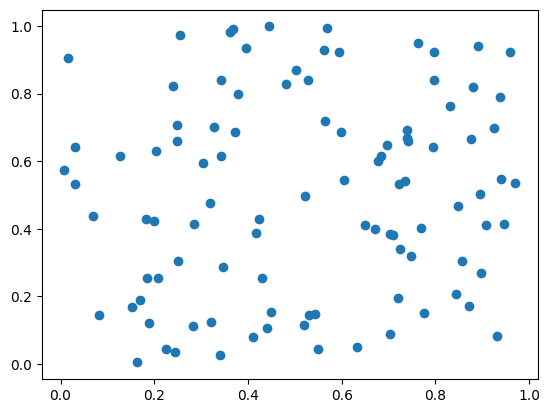

In [ ]:
n = 100
data = np.random.rand(n, 2)

plt.scatter(data[:, 0], data[:, 1])
plt.show();

Строим дерево

In [ ]:
tree = KDTree(data, leaf_size=3)

Ищем в дереве

In [ ]:
k = 10
point = np.array([[0.2, 0.7]])

distances, indices = tree.query(point, k=k)
distances, indices

(array([[0.04823409, 0.06241389, 0.06992972, 0.11263259, 0.1274356 ,
         0.12771188, 0.14770125, 0.16536128, 0.17180119, 0.17949775]]),
 array([[21, 19, 73, 97, 31, 86, 64, 24, 69, 87]]))

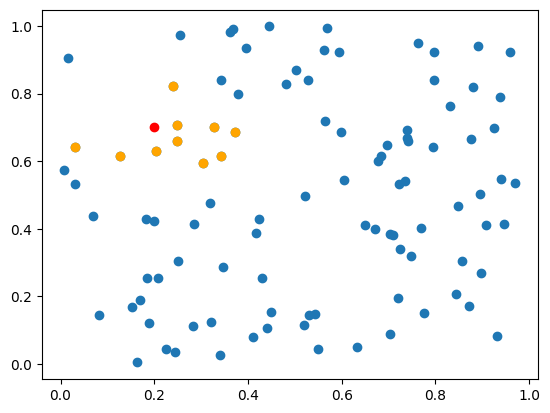

In [ ]:
plt.scatter(data[:, 0], data[:, 1])
plt.scatter(data[indices[0], 0], data[indices[0], 1], color='orange')
plt.scatter(point[:, 0], point[:, 1], color='red')
plt.show();

### BallTree

BallTree решает ту же задачу, что и KD-tree, но другим способом.

<img src="https://www.researchgate.net/publication/351985320/figure/fig1/AS:1029206997737472@1622393478361/An-example-of-the-ball-tree-All-points-will-be-finally-assigned-to-a-leaf-node.png">

Алгоритм построения:
1. Берем координату (часто координату выбирают по принципу максимизации дисперсии), для нее подбираем два центра шаров так, чтобы точки максимально равномерно распределились между двумя шарами.
2. Повторяем пункт 1 для каждого из шаров, пока не получим дочерние шарики (листья) заданного размера.

In [ ]:
from sklearn.neighbors import BallTree

Результат работы алгоритма, очевидно, будет тот же, что и для KD-Tree, так как исходные точки, как и расстояния между ними, не изменились

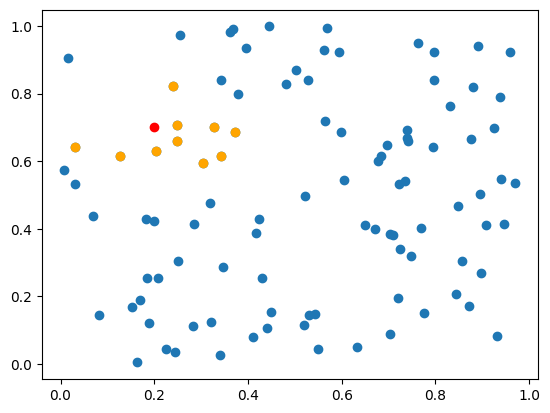

In [ ]:
tree = BallTree(data, leaf_size=3)

k = 10
point = np.array([[0.2, 0.7]])

distances, indices = tree.query(point, k=k)
distances, indices

plt.scatter(data[:, 0], data[:, 1])
plt.scatter(data[indices[0], 0], data[indices[0], 1], color='orange')
plt.scatter(point[:, 0], point[:, 1], color='red')
plt.show();

**Сравнение алгоритмов**

| Характеристика              | **KDTree**                                                  | **BallTree**                                                  |
|----------------------------|--------------------------------------------------------------|---------------------------------------------------------------|
| **Принцип**                 | Разделение по осям (гиперплоскостями)                        | Разделение на сферы ("шары")                                  |
| **Лучшая размерность**      | Низкая (≤ 15–20 признаков)                                   | Высокая (> 20 признаков)                                      |
| **Тип данных**              | Равномерно распределённые                                    | Кластеризованные, неравномерные                               |
| **Тип расстояний**         | Евклидово, Манхэттен, Чебышев (L1/L2/L∞)                     | Любые метрики (включая косинусную, корреляционную и т.д.)     |
| **Скорость построения**    | Быстрее                                                     | Медленнее                                                     |
| **Скорость поиска**        | Быстрее при низкой размерности                              | Быстрее при высокой размерности                               |

>Расстояние Чебышева: $D_{\text{Chebyshev}}(x, y) = \max_{i} \left| x_i - y_i \right|$
